# Time Series Analysis & Anomaly Detection for Multiple Humidity Sensors in a Warehouse 

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm

In [2]:
file_path = r"C:\\Users\\sulaiman.at\\Documents\\GitHub\\TSA&F-Humidity-Warehouse\\RawData2.xls"
# Load the data
data = pd.read_excel(file_path, engine="xlrd", sheet_name=None) # Load all sheets into a dictionary

# Combine sheets (assuming common date column)
combined_df = pd.DataFrame()
for sheet_name, df in data.items():
    df['SourceSheet'] = sheet_name # Optional: track source
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# Set the date column as the index
combined_df['Date'] = pd.to_datetime(combined_df['Time'])
combined_df.set_index('Date', inplace=True)

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero


In [3]:
combined_df.head()

,Index,Time,CH01(%),CH02(%),CH03(%),CH04(%),CH05(%),CH06(%),SourceSheet
Date,,,,,,,,,
2025-02-27 10:04:44,1,02/27/2025 10:04:44 AM,80.21,78.64,76.12,77.16,78.87,78.25,sheet1
2025-02-27 10:05:04,2,02/27/2025 10:05:04 AM,80.08,78.63,76.11,77.18,78.87,78.12,sheet1
2025-02-27 10:05:24,3,02/27/2025 10:05:24 AM,79.94,78.63,76.12,77.15,78.85,78.09,sheet1
2025-02-27 10:05:44,4,02/27/2025 10:05:44 AM,79.95,78.64,76.11,77.28,78.85,78.12,sheet1
2025-02-27 10:06:04,5,02/27/2025 10:06:04 AM,79.92,78.62,76.11,77.17,78.84,78.12,sheet1


In [4]:
combined_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 39212 entries, 2025-02-27 10:04:44 to 2025-03-08 11:55:04
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Index        39212 non-null  int64  
 1   Time         39212 non-null  str    
 2   CH01(%)      39212 non-null  float64
 3   CH02(%)      39212 non-null  float64
 4   CH03(%)      39212 non-null  float64
 5   CH04(%)      39212 non-null  float64
 6   CH05(%)      39212 non-null  float64
 7   CH06(%)      39212 non-null  float64
 8   SourceSheet  39212 non-null  str    
dtypes: float64(6), int64(1), str(2)
memory usage: 3.0 MB


In [5]:

# Convert Time column from string to datetime
combined_df['Time'] = pd.to_datetime(combined_df['Time'], format='mixed')

# Set Time as index for time series analysis
combined_df = combined_df.set_index('Time')


In [7]:
combined_df.index.is_monotonic_increasing

# If returns False, sort the index
# combined_df = combined_df.sort_index()

True

In [8]:
# Remove impossible humidity values
combined_df = combined_df.replace(-32640, pd.NA)

# Drop rows where all channels are missing
combined_df = combined_df.dropna(how='all')

# Drop the source sheet column if it exists
combined_df = combined_df.drop(columns=['SourceSheet'], errors='ignore') 

In [10]:
combined_df.head()

,Index,CH01(%),CH02(%),CH03(%),CH04(%),CH05(%),CH06(%)
Time,,,,,,,
2025-02-27 10:04:44,1,80.21,78.64,76.12,77.16,78.87,78.25
2025-02-27 10:05:04,2,80.08,78.63,76.11,77.18,78.87,78.12
2025-02-27 10:05:24,3,79.94,78.63,76.12,77.15,78.85,78.09
2025-02-27 10:05:44,4,79.95,78.64,76.11,77.28,78.85,78.12
2025-02-27 10:06:04,5,79.92,78.62,76.11,77.17,78.84,78.12


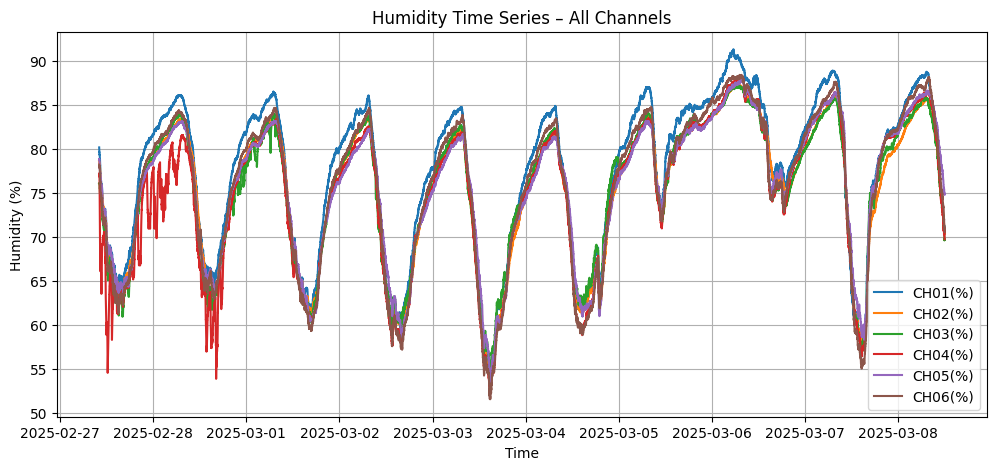

In [12]:

# Convert all columns to numeric and coerce errors to NaN (in case there are any non-numeric values)
combined_df = combined_df.apply(pd.to_numeric, errors='coerce')

# Drop the non-sensor column if it exists
combined_df = combined_df.drop(columns=['Index'], errors='ignore')

plt.figure(figsize=(12,5))
for col in combined_df.columns:
    plt.plot(combined_df.index, combined_df[col], label=col)

plt.title("Humidity Time Series – All Channels")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()


**Remove the trend**

In [15]:
first_diff = combined_df.diff()
first_diff.dropna(inplace=True)

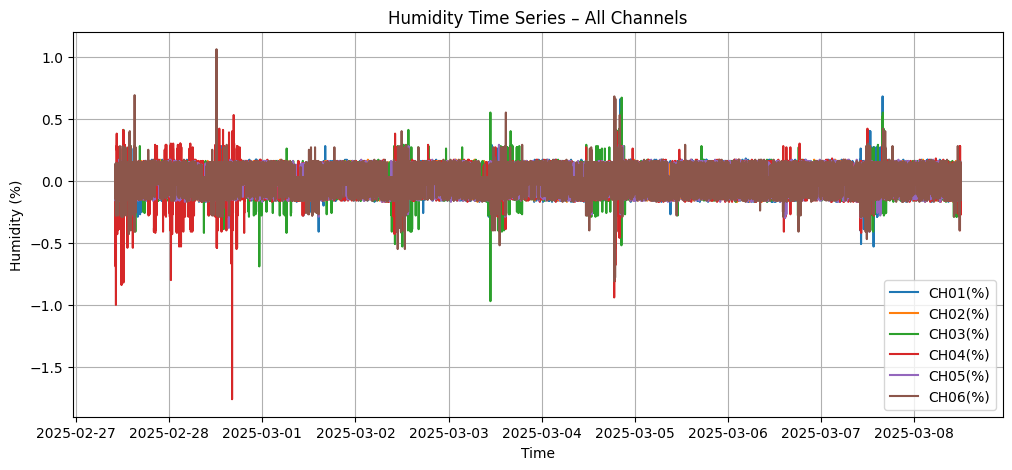

In [16]:
plt.figure(figsize=(12,5))
for col in first_diff.columns:
    plt.plot(first_diff.index, first_diff[col], label=col)

plt.title("Humidity Time Series – All Channels")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
# Choose one channel
y = combined_df['CH04(%)'].copy()

# Ensure numeric and handle error codes
y = pd.to_numeric(y, errors='coerce').replace(-32640, np.nan)

# Sort time
y = y.sort_index()

# Align timestamps to nearest n minutes and aggregate duplicates
n = 60  # Example: align to nearest 60 minutes
y.index = y.index.round(f'{n}min')
y = y.groupby(level=0).mean()

# Enforce strict n-min frequency
y = y.asfreq(f'{n}min')

# Fill small gaps (safe for short-term forecasting)
y = y.interpolate('time').ffill().bfill()

# Train/test split
split = int(len(y) * 0.8)
train = y.iloc[:split]
test  = y.iloc[split:]  

In [37]:

model = pm.auto_arima(
    train,
    seasonal=False,        
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=720.920, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=810.256, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=733.140, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=767.894, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=808.270, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=718.929, Time=0.07 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=729.624, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=730.030, Time=0.05 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=720.927, Time=0.12 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=724.791, Time=0.08 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=721.381, Time=0.08 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.40 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=716.939, Time=0.04 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=727.624, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=728.038, 

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  175
Model:               SARIMAX(3, 1, 1)   Log Likelihood                -342.838
Date:                Wed, 01 Apr 2026   AIC                            695.675
Time:                        16:09:12   BIC                            711.470
Sample:                    02-27-2025   HQIC                           702.083
                         - 03-06-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2916      0.057     22.697      0.000       1.180       1.403
ar.L2         -0.0044      0.092     -0.048      0.962      -0.185       0.176
ar.L3         -0.4104      0.057     -7.153      0.000      -0.523      -0.298
ma.L1         -0.9542      0.043    -22.171      0.000      -1.039      -0.870
sigma2         2.9748      0.260     11.427      0.000       2.465       3.485
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):                30.64
Prob(Q):                              0.79   Prob(JB):                         0.00
Heteroskedasticity (H):               0.79   Skew:                            -0.20
Prob(H) (two-sided):                  0.36   Kurtosis:                         5.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

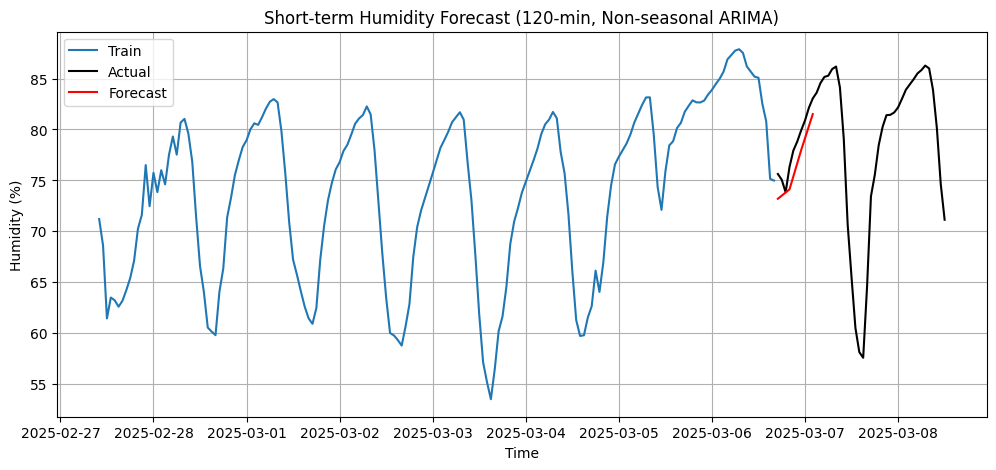

In [38]:

n_periods = 12
forecast = model.predict(n_periods=n_periods)

forecast_index = pd.date_range(start=test.index[0], periods=n_periods, freq='180min')
forecast_series = pd.Series(forecast, index=forecast_index)

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", color="black")
plt.plot(forecast_series.index, forecast_series, label="Forecast", color="red")
plt.title("Short-term Humidity Forecast (120-min, Non-seasonal ARIMA)")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.grid(True)
plt.legend()
plt.show()


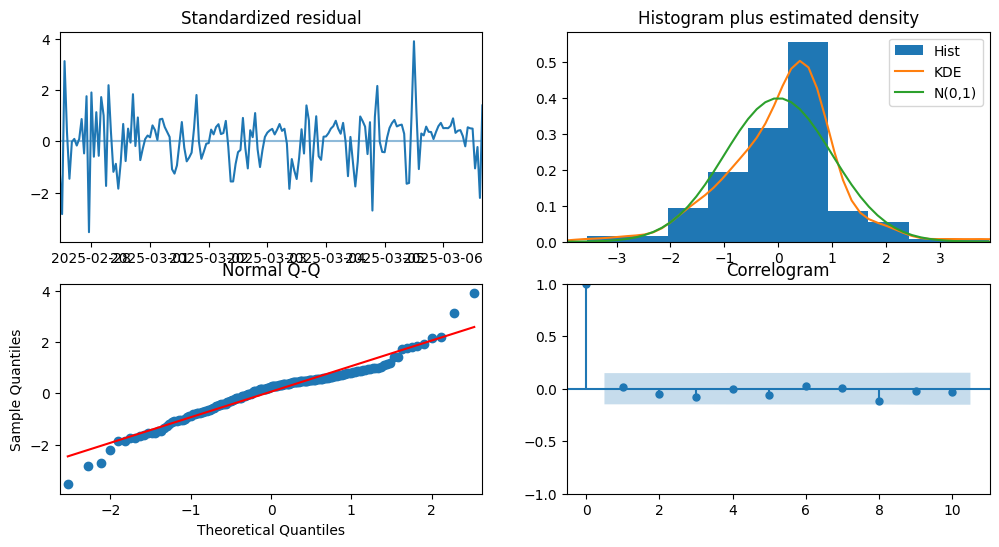

In [39]:
model.plot_diagnostics(figsize=(12,6))
plt.show()


In [40]:

simple_model = pm.ARIMA(order=(1,0,1), with_intercept=True)
simple_model.fit(train)


n_periods = 12

# Complex model forecast
fc_complex = model.predict(n_periods=n_periods)

# Simple model forecast
fc_simple = simple_model.predict(n_periods=n_periods)
                                 
                                 
actual = test.iloc[:n_periods]

mae_complex = mean_absolute_error(actual, fc_complex)
mae_simple  = mean_absolute_error(actual, fc_simple)

print("Complex ARIMA(2,0,4) MAE:", mae_complex)
print("Simple  ARIMA(1,0,1) MAE:", mae_simple)



Complex ARIMA(2,0,4) MAE: 1.8411254359557045
Simple  ARIMA(1,0,1) MAE: 4.549138510730306


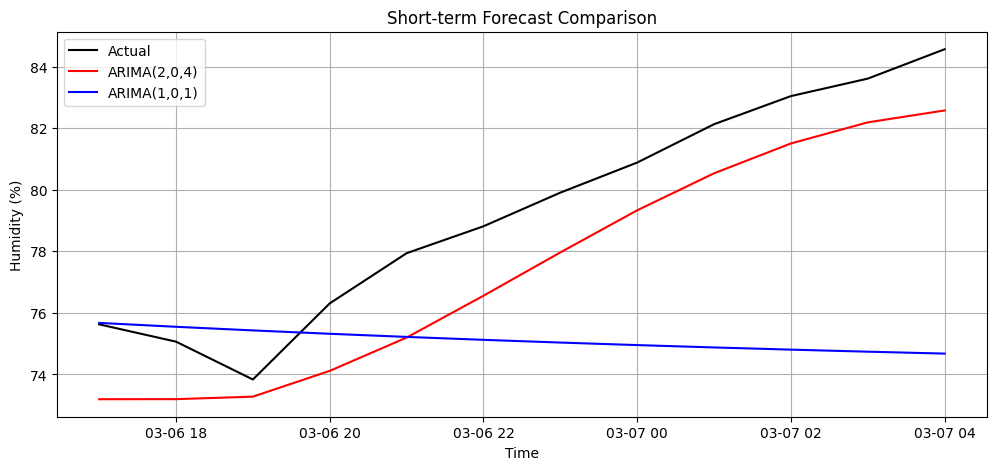

In [41]:

plt.figure(figsize=(12,5))
plt.plot(test.index[:n_periods], actual, label="Actual", color="black")
plt.plot(test.index[:n_periods], fc_complex, label="ARIMA(2,0,4)", color="red")
plt.plot(test.index[:n_periods], fc_simple, label="ARIMA(1,0,1)", color="blue")

plt.title("Short-term Forecast Comparison")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()
